In [1]:
#importing libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,recall_score,precision_score,f1_score
from sklearn.model_selection import train_test_split, GridSearchCV, ParameterGrid
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_selection import SelectKBest,f_classif



wine_df = pd.read_csv("wine.csv")
chickwts_df = pd.read_csv("chickwts.csv")
arrests_df = pd.read_csv("USArrests.csv")

print(wine_df.head())
print(chickwts_df.head())
print(arrests_df.head())



   Wine  Alcohol  Malic.acid   Ash   Acl   Mg  Phenols  Flavanoids  \
0     1    14.23        1.71  2.43  15.6  127     2.80        3.06   
1     1    13.20        1.78  2.14  11.2  100     2.65        2.76   
2     1    13.16        2.36  2.67  18.6  101     2.80        3.24   
3     1    14.37        1.95  2.50  16.8  113     3.85        3.49   
4     1    13.24        2.59  2.87  21.0  118     2.80        2.69   

   Nonflavanoid.phenols  Proanth  Color.int   Hue    OD  Proline  
0                  0.28     2.29       5.64  1.04  3.92     1065  
1                  0.26     1.28       4.38  1.05  3.40     1050  
2                  0.30     2.81       5.68  1.03  3.17     1185  
3                  0.24     2.18       7.80  0.86  3.45     1480  
4                  0.39     1.82       4.32  1.04  2.93      735  
   rownames  weight       feed
0         1     179  horsebean
1         2     160  horsebean
2         3     136  horsebean
3         4     227  horsebean
4         5     217  h

In [86]:
#Checikng info for the datasets and dataset sizes
print(wine_df.info())

print(chickwts_df.info())

print(arrests_df.info())



print(f"Wine:",wine_df.shape)
print(f"Chickwts:",chickwts_df.shape)
print(f"Arrests:",arrests_df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Wine                  178 non-null    int64  
 1   Alcohol               178 non-null    float64
 2   Malic.acid            178 non-null    float64
 3   Ash                   178 non-null    float64
 4   Acl                   178 non-null    float64
 5   Mg                    178 non-null    int64  
 6   Phenols               178 non-null    float64
 7   Flavanoids            178 non-null    float64
 8   Nonflavanoid.phenols  178 non-null    float64
 9   Proanth               178 non-null    float64
 10  Color.int             178 non-null    float64
 11  Hue                   178 non-null    float64
 12  OD                    178 non-null    float64
 13  Proline               178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB
None
<class 'pandas.DataFrame'>
RangeI

In [87]:
#Summary statistics for the datasets

print(wine_df.describe())

print(chickwts_df.describe())

print(arrests_df.describe())

             Wine     Alcohol  Malic.acid         Ash         Acl          Mg  \
count  178.000000  178.000000  178.000000  178.000000  178.000000  178.000000   
mean     1.938202   13.000618    2.336348    2.366517   19.494944   99.741573   
std      0.775035    0.811827    1.117146    0.274344    3.339564   14.282484   
min      1.000000   11.030000    0.740000    1.360000   10.600000   70.000000   
25%      1.000000   12.362500    1.602500    2.210000   17.200000   88.000000   
50%      2.000000   13.050000    1.865000    2.360000   19.500000   98.000000   
75%      3.000000   13.677500    3.082500    2.557500   21.500000  107.000000   
max      3.000000   14.830000    5.800000    3.230000   30.000000  162.000000   

          Phenols  Flavanoids  Nonflavanoid.phenols     Proanth   Color.int  \
count  178.000000  178.000000            178.000000  178.000000  178.000000   
mean     2.295112    2.029270              0.361854    1.590899    5.058090   
std      0.625851    0.998859    

In [88]:
#Checking for missing values
print(wine_df.isna().sum())

print(chickwts_df.isna().sum())

print(arrests_df.isna().sum())

Wine                    0
Alcohol                 0
Malic.acid              0
Ash                     0
Acl                     0
Mg                      0
Phenols                 0
Flavanoids              0
Nonflavanoid.phenols    0
Proanth                 0
Color.int               0
Hue                     0
OD                      0
Proline                 0
dtype: int64
rownames    0
weight      0
feed        0
dtype: int64
Murder      0
Assault     0
UrbanPop    0
Rape        0
State       0
dtype: int64


In [89]:
print(wine_df.duplicated().sum())

print(chickwts_df.duplicated().sum())

print(arrests_df.duplicated().sum())

0
0
0


## PREPARATION OF WINE DATASET

In [90]:
wine_df['Wine'].unique()

array([1, 2, 3])

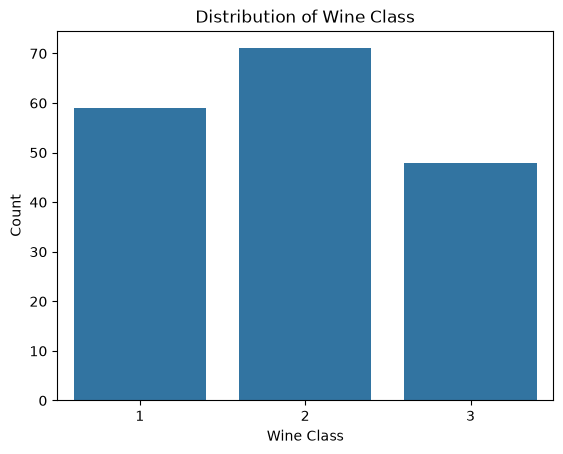

In [91]:
# A barchart to help us know distribution of the target variable in the wine dataset
wine_target = 'Wine'

X_wine = wine_df.drop(columns=[wine_target])
y_wine= wine_df[wine_target]

sns.countplot(data=wine_df,x='Wine')
plt.xlabel('Wine Class')
plt.ylabel('Count')
plt.title('Distribution of Wine Class')
plt.show()

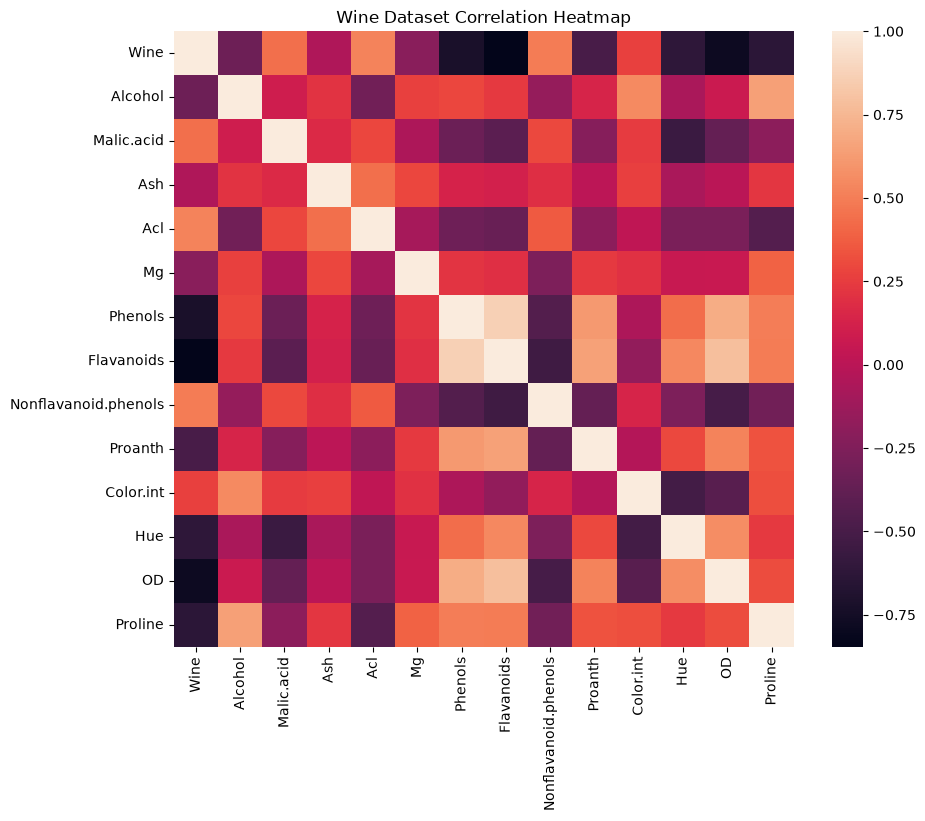

In [92]:
#A correlation heatmap to help visualize the  relationships between the numerical features in the wine dataset
wine_df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(wine_df.corr(numeric_only=True))
plt.title('Wine Dataset Correlation Heatmap')
plt.show()

In [93]:
wine_target = 'Wine'
X_wine = wine_df.drop(columns=[wine_target])
y_wine=wine_df[wine_target]

## PREPARATION FOR CHICKWTS DATASET

In [94]:
#preparation for chickwts

chickwts_df['feed'].value_counts()

feed
soybean      14
linseed      12
sunflower    12
casein       12
meatmeal     11
horsebean    10
Name: count, dtype: int64

feed
casein       323.583333
horsebean    160.200000
linseed      218.750000
meatmeal     276.909091
soybean      246.428571
sunflower    328.916667
Name: weight, dtype: float64


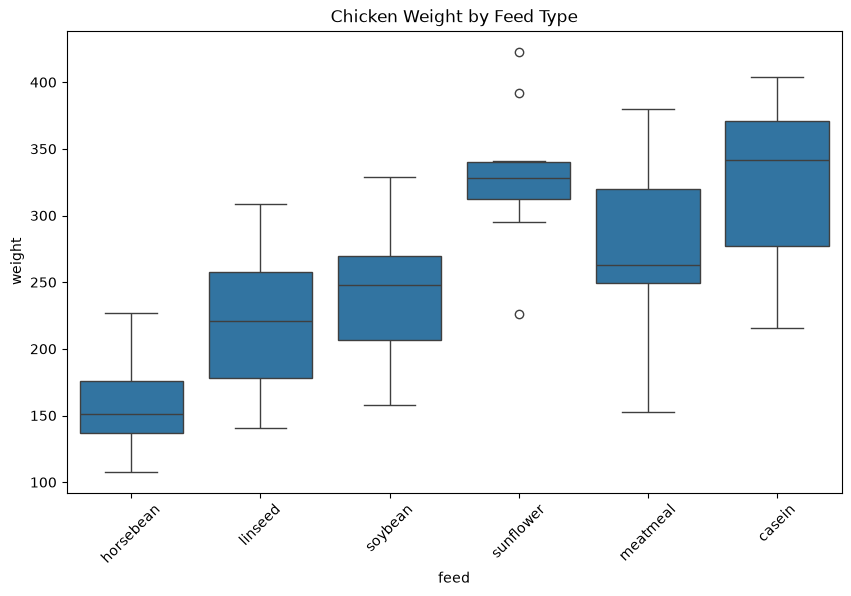

In [95]:
print(chickwts_df.groupby('feed')['weight'].mean())
# A boxplot to visualize the distribution of chicken weights across different feed types
plt.figure(figsize=(10,6))
sns.boxplot(data=chickwts_df,x='feed',y='weight')
plt.title('Chicken Weight by Feed Type')
plt.xticks(rotation=45)
plt.show()



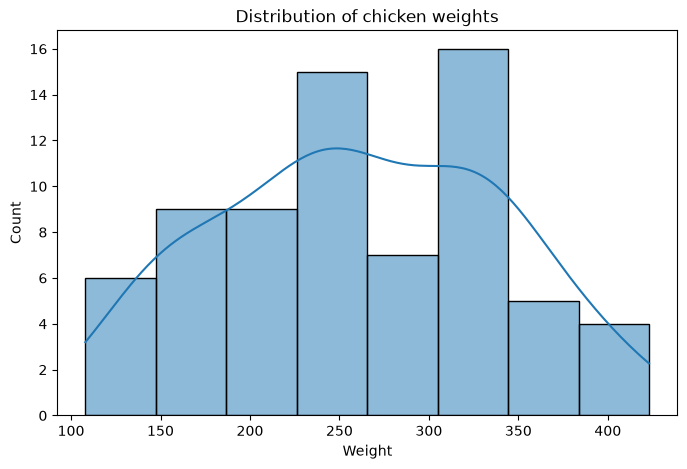

In [96]:
#A histogram to visualize the distribution of chicken weights
plt.figure(figsize=(8,5))
sns.histplot(chickwts_df['weight'],kde=True)
plt.title("Distribution of chicken weights")
plt.xlabel('Weight')
plt.show()

In [97]:
X_chick = chickwts_df['weight']

## PREPARATION OF USArrests DATASET

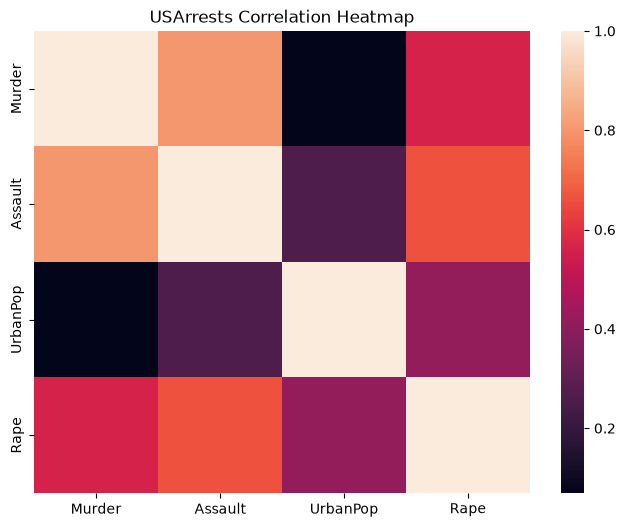

In [98]:
#Preparing USArrests
#A correlation heatmap to help visualize the relationships between the numerical features in the USArrests dataset
arrests_df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(arrests_df.corr(numeric_only=True))
plt.title('USArrests Correlation Heatmap')
plt.show()

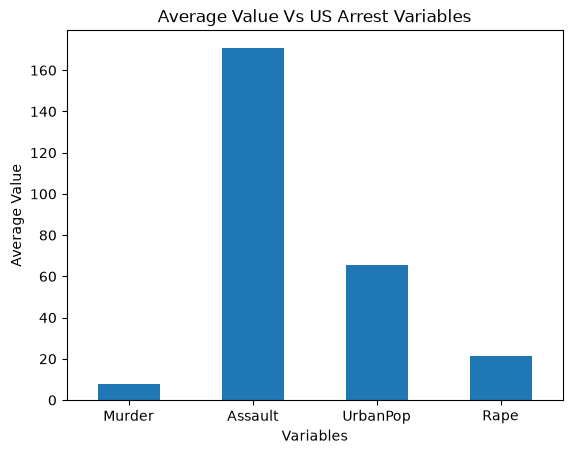

In [99]:
#A bar chart to visualize the average values of the variables in the USArrests dataset
arrests_df[['Murder','Assault','UrbanPop','Rape']].mean().plot(kind='bar')
plt.xlabel('Variables')
plt.ylabel('Average Value')
plt.title('Average Value Vs US Arrest Variables')
plt.xticks(rotation=0)
plt.show()


In [100]:
X_arrests = arrests_df[['Murder','Assault','UrbanPop','Rape']]

## PREPROCESSING AND MODELLING FOR WINE DATASET

In [101]:
#Wine Dataset
#Identifying numerical and categorical columns

numerical_wine = X_wine.select_dtypes(include=['int64','float64']).columns
categorical_wine = X_wine.select_dtypes(include=['object','category']).columns
print("Numerical_wine:",list(numerical_wine))
print("Categorical_wine:",list(categorical_wine))

Numerical_wine: ['Alcohol', 'Malic.acid', 'Ash', 'Acl', 'Mg', 'Phenols', 'Flavanoids', 'Nonflavanoid.phenols', 'Proanth', 'Color.int', 'Hue', 'OD', 'Proline']
Categorical_wine: []


In [102]:
#Splitting Data
X_train_wine,X_test_wine,y_train_wine,y_test_wine = train_test_split(
    X_wine,
    y_wine,
    test_size = 0.2,
    random_state=42,
    stratify=y_wine
)

In [103]:
#Preprocess numerical variables
#Since wine is numerical we use Standardscaler

scaler_wine = StandardScaler()
X_train_scaled = scaler_wine.fit_transform(X_train_wine)
X_test_wine_scaled = scaler_wine.transform(X_test_wine)

## PREPROCESSING AND MODELLING FOR CHICKWTS DATASET

In [112]:
#Chickwits Dataset
#identify numerical and categorical columns

numerical_chick = chickwts_df.select_dtypes(include=['int64','float64']).columns
categorical_chick = chickwts_df.select_dtypes(include=['object','category']).columns

print("Numerical Chick:",list(numerical_chick))
print("Categorical Chick:",list(categorical_chick))

Numerical Chick: ['weight']
Categorical Chick: ['feed']


C:\Users\USER\AppData\Local\Temp\ipykernel_9952\171609179.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_chick = chickwts_df.select_dtypes(include=['object','category']).columns


## PREPROCESSING AND MODELLING USArrest DATASET

In [ ]:
numerical_arrests = arrests_df.select_dtypes(include=['int64','float64']).columns
categorical_arrests = arrests_df.select_dtypes(include=['object','category']).columns

print("Numerical Arrests:",list(numerical_arrests))
print("Categorical_Arrests:",list(categorical_arrests))

Numerical Arrests: ['Murder', 'Assault', 'UrbanPop', 'Rape']
Categorical_Arrests: ['State']


C:\Users\USER\AppData\Local\Temp\ipykernel_9952\1689911604.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_arrests = arrests_df.select_dtypes(include=['object','category']).columns


In [ ]:
X_arrests = arrests_df[['Murder','Assault','UrbanPop','Rape']]

In [ ]:
X_arrests.isnull().sum()

Murder      0
Assault     0
UrbanPop    0
Rape        0
dtype: int64

In [111]:
scaler_arrests = StandardScaler()
X_arrests_scaled = scaler_arrests.fit_transform(X_arrests)